# Figure 3(d): the 15 submitted configurations, at the full seed count


In [7]:
import csv, json, re, ast
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

WORKDIR = Path('.').resolve()
CKPT = next(p for p in [WORKDIR / 'item1_all33',
                        WORKDIR.parent / 'rebuttal' / 'consolidated_experiments' / 'item1_all33']
            if p.exists() and any(p.glob('*.npz')))

# Seed list: single source of truth = the all33 notebook.
_nb = json.loads((WORKDIR / 'item1_all33_seeds.ipynb').read_text())
_src = next(''.join(c['source']) for c in _nb['cells'] if 'SEEDS = [' in ''.join(c['source']))
_lit = _src[_src.index('SEEDS = ['):]
SEEDS = ast.literal_eval(_lit[_lit.index('['):_lit.index(']') + 1])
print(f'checkpoints: {CKPT}')
print(f'{len(SEEDS)} seeds from item1_all33_seeds.ipynb: {SEEDS[:12]}{"..." if len(SEEDS)>12 else ""}')

FILT, M = 0.005, 50
CONFIGS = [  # the 15 of the submitted figure, from its legends
    ('ReLU rt4 e2.0',   'relu_p100_rt4_rs50_n15000_eta2.0',   'relu',  4),
    ('ReLU rt6 e1.5',   'relu_p100_rt6_rs50_n15000_eta1.5',   'relu',  6),
    ('ReLU rt8 e1.5',   'relu_p100_rt8_rs50_n15000_eta1.5',   'relu',  8),
    ('ReLU rt12 e1.5',  'relu_p100_rt12_rs50_n15000_eta1.5',  'relu', 12),
    ('ReLU rt16 e2.0',  'relu_p100_rt16_rs50_n15000_eta2.0',  'relu', 16),
    ('GELU rt4 e0.7',   'gelu_p100_rt4_rs50_n15000_eta0.7',   'gelu',  4),
    ('GELU rt8 e0.7',   'gelu_p100_rt8_rs50_n15000_eta0.7',   'gelu',  8),
    ('GELU rt12 e0.7',  'gelu_p100_rt12_rs50_n15000_eta0.7',  'gelu', 12),
    ('GELU rt16 e0.7',  'gelu_p100_rt16_rs50_n15000_eta0.7',  'gelu', 16),
    ('GELU rt16 e0.85', 'gelu_p100_rt16_rs50_n15000_eta0.85', 'gelu', 16),
    ('SiLU rt4 e0.85',  'silu_p100_rt4_rs50_n15000_eta0.85',  'silu',  4),
    ('SiLU rt8 e0.85',  'silu_p100_rt8_rs50_n15000_eta0.85',  'silu',  8),
    ('SiLU rt12 e0.85', 'silu_p100_rt12_rs50_n15000_eta0.85', 'silu', 12),
    ('SiLU rt16 e0.85', 'silu_p100_rt16_rs50_n15000_eta0.85', 'silu', 16),
    ('SiLU rt20 e0.85', 'silu_p100_rt20_rs50_n15000_eta0.85', 'silu', 20),
]
COL = {'relu': 'tab:blue', 'gelu': 'tab:orange', 'silu': 'tab:green'}

print(f"\n{'config':18s} {'seeds found':>11s}   (of the {len(SEEDS)} listed)")
AVAIL = {}
for lab, base, act, rt in CONFIGS:
    have = sorted(int(re.search(r'seed(\d+)', f.name).group(1))
                  for f in CKPT.glob(base + '_seed*.npz')
                  if int(re.search(r'seed(\d+)', f.name).group(1)) in SEEDS)
    AVAIL[lab] = have
    tag = '' if len(have) == len(SEEDS) else '   <-- dropped-from-grid config, old seeds only'
    print(f'{lab:18s} {len(have):>11d}{tag}')


checkpoints: /u/akumar3/akum/Muon_SGD/review_session/consolidated_exp_comments/item1_all33
50 seeds from item1_all33_seeds.ipynb: [5, 11, 23, 37, 41, 53, 67, 71, 83, 97, 101, 103]...

config             seeds found   (of the 50 listed)
ReLU rt4 e2.0               50
ReLU rt6 e1.5               50
ReLU rt8 e1.5               50
ReLU rt12 e1.5              50
ReLU rt16 e2.0              50
GELU rt4 e0.7               50
GELU rt8 e0.7               50
GELU rt12 e0.7              50
GELU rt16 e0.7              50
GELU rt16 e0.85             50
SiLU rt4 e0.85              50
SiLU rt8 e0.85              50
SiLU rt12 e0.85             50
SiLU rt16 e0.85             50
SiLU rt20 e0.85             50


## Per-run metrics

For every available run: the submitted pipeline's late-half secant (and its
filter variable, the late-half change), plus the saturation-proof peak
500-step rate.


In [8]:
def dedupe(s, y):
    s = np.asarray(s, float); y = np.asarray(y, float)
    _, i = np.unique(s, return_index=True)
    return s[i], y[i]

def metrics(f):
    z = np.load(f, allow_pickle=True)
    s, cm = dedupe(z['step'], z['cos2_min_AGOP'])
    i = len(cm) // 2
    change = cm[-1] - cm[i]
    secant = change / (s[-1] - s[i])
    w = max(2, int(round(500 / (s[1] - s[0]))))
    peak = float(np.max((cm[w:] - cm[:-w]) / (s[w:] - s[:-w])))
    return change, secant, peak

RUNS = []
for lab, base, act, rt in CONFIGS:
    for sd in AVAIL[lab]:
        ch, sec, pk = metrics(CKPT / f'{base}_seed{sd}.npz')
        RUNS.append(dict(label=lab, act=act, r_t=rt, x=rt / M, seed=sd,
                         change=ch, secant=sec, peak=pk))
print(f'{len(RUNS)} runs scored')
with open('fig3d_15config_perrun.csv', 'w', newline='') as fh:
    w = csv.DictWriter(fh, fieldnames=RUNS[0].keys()); w.writeheader(); w.writerows(RUNS)
print('wrote fig3d_15config_perrun.csv')


750 runs scored
wrote fig3d_15config_perrun.csv


## Fits

Three numbers, matching the earlier comparison: the published pipeline on
config medians (filter on median change), the same per-run, and the
peak-rate estimator on all 15 with a config-level bootstrap CI.


In [9]:
def fit_loglog(x, y):
    lx, ly = np.log(x), np.log(y)
    a, b = np.polyfit(lx, ly, 1)
    r2 = 1 - ((ly - (a*lx+b))**2).sum() / ((ly - ly.mean())**2).sum()
    return a, b, r2

def boot_ci(x, y, B=4000, seed=0):
    lx, ly = np.log(x), np.log(y)
    rng = np.random.default_rng(seed)
    bs = [np.polyfit(lx[i], ly[i], 1)[0]
          for i in (rng.integers(0, len(x), len(x)) for _ in range(B))]
    return np.percentile(bs, [2.5, 97.5])

byc = defaultdict(list)
for r in RUNS: byc[r['label']].append(r)
MED = []
for lab, base, act, rt in CONFIGS:
    v = byc[lab]
    MED.append(dict(label=lab, act=act, x=rt / M, n=len(v),
                    change_med=float(np.median([r['change'] for r in v])),
                    secant_med=float(np.median([r['secant'] for r in v])),
                    secant_q1=float(np.percentile([r['secant'] for r in v], 25)),
                    secant_q3=float(np.percentile([r['secant'] for r in v], 75)),
                    peak_med=float(np.median([r['peak'] for r in v])),
                    peak_q1=float(np.percentile([r['peak'] for r in v], 25)),
                    peak_q3=float(np.percentile([r['peak'] for r in v], 75))))
for m in MED: m['filtered'] = m['change_med'] < FILT

kept = [m for m in MED if not m['filtered']]
xk = np.array([m['x'] for m in kept]); yk = np.array([m['secant_med'] for m in kept])
a_sec, b_sec, r2_sec = fit_loglog(xk, yk)
lo_s, hi_s = boot_ci(xk, yk)
xr = np.array([r['x'] for r in RUNS if r['change'] >= FILT])
yr = np.array([r['secant'] for r in RUNS if r['change'] >= FILT])
a_pr, _, r2_pr = fit_loglog(xr, yr)
xp = np.array([m['x'] for m in MED]); yp = np.array([m['peak_med'] for m in MED])
a_pk, b_pk, r2_pk = fit_loglog(xp, yp)
lo_p, hi_p = boot_ci(xp, yp)

N = max(m['n'] for m in MED)
print(f'published reference (1 seed)      : a = +2.12  R2 0.46  12/15 kept')
print(f'10-seed reference                 : a = +1.78  R2 0.37  12/15 kept')
print(f'THIS RUN, secant medians + filter : a = {a_sec:+.2f}  [{lo_s:+.2f},{hi_s:+.2f}]  R2 {r2_sec:.2f}  {len(kept)}/15 kept  (up to {N} seeds)')
print(f'THIS RUN, secant per-run + filter : a = {a_pr:+.2f}  R2 {r2_pr:.2f}  on {len(xr)} runs')
print(f'THIS RUN, peak-rate medians, all  : a = {a_pk:+.2f}  [{lo_p:+.2f},{hi_p:+.2f}]  R2 {r2_pk:.2f}  15/15')
print('filtered:', [m['label'] for m in MED if m['filtered']])


published reference (1 seed)      : a = +2.12  R2 0.46  12/15 kept
10-seed reference                 : a = +1.78  R2 0.37  12/15 kept
THIS RUN, secant medians + filter : a = +1.82  [+0.29,+2.87]  R2 0.47  12/15 kept  (up to 50 seeds)
THIS RUN, secant per-run + filter : a = +1.79  R2 0.32  on 584 runs
THIS RUN, peak-rate medians, all  : a = -1.33  [-1.82,-0.90]  R2 0.68  15/15
filtered: ['ReLU rt4 e2.0', 'GELU rt4 e0.7', 'SiLU rt4 e0.85']


## Figure


In [10]:
# fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))
# FLOOR = 1.2e-6
# xs = np.linspace(0.07, 0.45, 60)
# STAG = {'GELU rt4 e0.7': (0.985, (7, 5)), 'SiLU rt4 e0.85': (1.015, (7, -13))}
# for m in MED:
#     for r in byc[m['label']]:
#         if r['secant'] > 0:
#             axA.scatter([m['x']], [r['secant']], s=7, color=COL[m['act']], alpha=0.18, zorder=2)
#     if m['filtered']:
#         jx, off = STAG.get(m['label'], (1.0, (7, -3)))
#         yv = max(abs(m['secant_med']), FLOOR)
#         axA.scatter([m['x']*jx], [yv], marker='v' if m['secant_med'] < 0 else '^', s=75,
#                     facecolors='none', edgecolors=COL[m['act']], linewidths=1.6, zorder=4)
#         axA.annotate(m['label'], (m['x']*jx, yv), textcoords='offset points',
#                      xytext=off, fontsize=6.8, color=COL[m['act']])
#     else:
#         axA.errorbar([m['x']], [m['secant_med']],
#                      yerr=[[m['secant_med']-m['secant_q1']], [m['secant_q3']-m['secant_med']]],
#                      fmt='o', ms=5.5, color=COL[m['act']], elinewidth=1.2, capsize=2.4,
#                      zorder=3, markeredgecolor='black', markeredgewidth=0.5)
# axA.plot(xs, np.exp(b_sec)*xs**a_sec, 'k-', lw=1.5,
#          label=f'this run: $a={a_sec:+.2f}$ [{lo_s:+.2f},{hi_s:+.2f}] ($R^2$={r2_sec:.2f})')
# b_pub = np.log(yk).mean() - 2.12*np.log(xk).mean()
# axA.plot(xs, np.exp(b_pub)*xs**2.12, color='0.55', ls='--', lw=1.4,
#          label='published (seed 5): $a=+2.12$')
# axA.set_xscale('log'); axA.set_yscale('log')
# axA.set_xlabel('$r_t/M$'); axA.set_ylabel('late-half secant of $\\cos^2_{\\min}$')
# axA.set_title(f'(i) submitted pipeline, {N}-seed medians\nsame 15 configs, same filter', fontsize=10)
# axA.legend(fontsize=7.2, loc='lower right'); axA.grid(alpha=.25, which='both', lw=.5)

# for m in MED:
#     mk = '^' if m['filtered'] else 'o'
#     axB.errorbar([m['x']], [m['peak_med']],
#                  yerr=[[m['peak_med']-m['peak_q1']], [m['peak_q3']-m['peak_med']]],
#                  fmt=mk, ms=6, color=COL[m['act']], elinewidth=1.2, capsize=2.4, zorder=3,
#                  markerfacecolor='none' if m['filtered'] else COL[m['act']],
#                  markeredgecolor=COL[m['act']] if m['filtered'] else 'black')
# axB.plot(xs, np.exp(b_pk)*xs**a_pk, 'k-', lw=1.5,
#          label=f'all 15: $a={a_pk:+.2f}$ [{lo_p:+.2f},{hi_p:+.2f}] ($R^2$={r2_pk:.2f})')
# axB.set_xscale('log'); axB.set_yscale('log')
# axB.set_xlabel('$r_t/M$'); axB.set_ylabel('peak rate of $\\cos^2_{\\min}$ [max 500-step slope]')
# axB.set_title(f'(ii) same runs, saturation-proof estimator\nnothing dropped', fontsize=10)
# axB.legend(fontsize=7.2, loc='lower left'); axB.grid(alpha=.25, which='both', lw=.5)

# hs = [plt.Line2D([], [], marker='o', ls='', color=c, label=a) for a, c in COL.items()]
# hs.append(plt.Line2D([], [], marker='^', ls='', markerfacecolor='none', color='0.3',
#                      label='filtered by the published rule'))
# axA.legend(handles=axA.get_legend_handles_labels()[0] + hs, fontsize=6.6,
#            loc='lower right', framealpha=.92)
# fig.tight_layout()
# fig.savefig('fig3d_15configs.png', dpi=170)
# print('saved fig3d_15configs.png')


saved fig3d_15configs.png


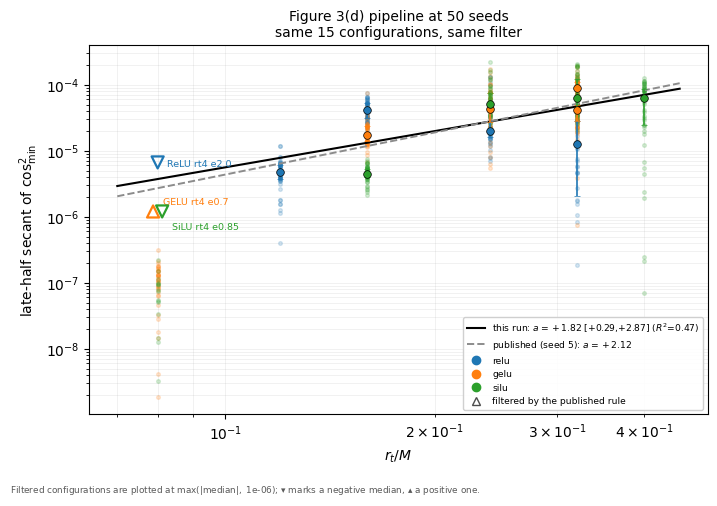

In [11]:
fig, axA = plt.subplots(figsize=(7.2, 5))
FLOOR = 1.2e-6
xs = np.linspace(0.07, 0.45, 60)
STAG = {'GELU rt4 e0.7': (0.985, (7, 5)), 'SiLU rt4 e0.85': (1.015, (7, -13))}
for m in MED:
    for r in byc[m['label']]:
        if r['secant'] > 0:
            axA.scatter([m['x']], [r['secant']], s=7, color=COL[m['act']], alpha=0.18, zorder=2)
    if m['filtered']:
        jx, off = STAG.get(m['label'], (1.0, (7, -3)))
        yv = max(abs(m['secant_med']), FLOOR)
        axA.scatter([m['x']*jx], [yv], marker='v' if m['secant_med'] < 0 else '^', s=75,
                    facecolors='none', edgecolors=COL[m['act']], linewidths=1.6, zorder=4)
        axA.annotate(m['label'], (m['x']*jx, yv), textcoords='offset points',
                     xytext=off, fontsize=6.8, color=COL[m['act']])
    else:
        axA.errorbar([m['x']], [m['secant_med']],
                     yerr=[[m['secant_med']-m['secant_q1']], [m['secant_q3']-m['secant_med']]],
                     fmt='o', ms=5.5, color=COL[m['act']], elinewidth=1.2, capsize=2.4,
                     zorder=3, markeredgecolor='black', markeredgewidth=0.5)
axA.plot(xs, np.exp(b_sec)*xs**a_sec, 'k-', lw=1.5,
         label=f'this run: $a={a_sec:+.2f}$ [{lo_s:+.2f},{hi_s:+.2f}] ($R^2$={r2_sec:.2f})')
b_pub = np.log(yk).mean() - 2.12*np.log(xk).mean()
axA.plot(xs, np.exp(b_pub)*xs**2.12, color='0.55', ls='--', lw=1.4,
         label='published (seed 5): $a=+2.12$')
axA.set_xscale('log'); axA.set_yscale('log')
axA.set_xlabel('$r_t/M$'); axA.set_ylabel('late-half secant of $\\cos^2_{\\min}$')
axA.set_title(f'Figure 3(d) pipeline at {N} seeds\nsame 15 configurations, same filter', fontsize=10)
axA.grid(alpha=.25, which='both', lw=.5)
hs = [plt.Line2D([], [], marker='o', ls='', color=c, label=a) for a, c in COL.items()]
hs.append(plt.Line2D([], [], marker='^', ls='', markerfacecolor='none', color='0.3',
                     label='filtered by the published rule'))
axA.legend(handles=axA.get_legend_handles_labels()[0] + hs, fontsize=6.6,
           loc='lower right', framealpha=.92)
fig.text(0.01, 0.005,
         'Filtered configurations are plotted at $\\max(|\\mathrm{median}|,$ '
         f'{FLOOR:.0e}$)$; $\\blacktriangledown$ marks a negative median, '
         '$\\blacktriangle$ a positive one.', fontsize=6.4, color='0.35')
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig('fig3d_15configs.png', dpi=170)
print('saved fig3d_15configs.png')